⏳ Calcul de l'ACP sur l'ensemble des dimensions...

--- Bilan de la sélection (Hors affichage) ---
📏 Nombre total de dimensions possibles : 159
🎯 Critère de Kaiser (>1)           : 4 composantes sélectionnées
🔸 Seuil de 80% de variance         : 5 composantes sélectionnées
🔸 Seuil de 90% de variance         : 6 composantes sélectionnées


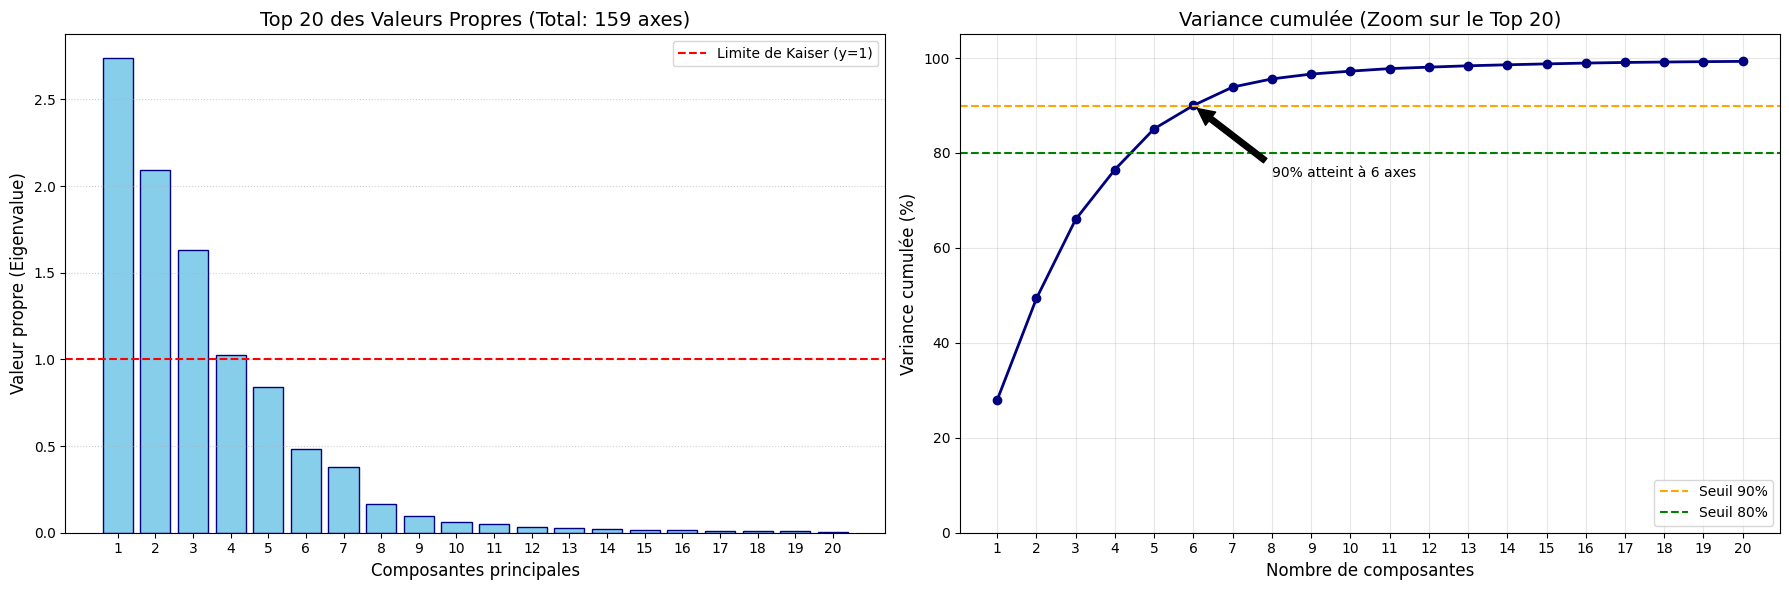

📊 Dimensions totales générées : 159
✅ Information conservée avec 20 composantes : 99.30%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA 

# --- 0. Chemins ---
PROJECT_PATH = Path("../").resolve()
DATA_PATH = PROJECT_PATH / "data"
DATA_TRAINING_SET_PATH = DATA_PATH / "UNSW_NB15_training-set.csv"

# --- 1. Chargement ---
df_train = pd.read_csv(DATA_TRAINING_SET_PATH)

# --- 2. Sélection ---
num_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl']
cat_features = ['proto', 'service', 'state']

# --- 3 & 4. Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scal', StandardScaler())]), num_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')), ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features)
    ]
)

# --- 5. Pipeline ACP Totale ---
# On ne met pas de n_components pour qu'il calcule TOUTES les composantes possibles
pipeline_full_pca = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA()) 
])

# --- 6. Exécution ---
print("⏳ Calcul de l'ACP sur l'ensemble des dimensions...")
X_all = pipeline_full_pca.fit_transform(df_train)

# --- 6.1 Extraction des métriques ---
pca_step = pipeline_full_pca.named_steps['pca']
valeurs_propres = pca_step.explained_variance_
variance_cumulee = np.cumsum(pca_step.explained_variance_ratio_) * 100
n_total = len(valeurs_propres)

# --- 6.1 Extraction des métriques (Zoom sur le Top 20) ---
pca_step = pipeline_full_pca.named_steps['pca']
valeurs_propres = pca_step.explained_variance_
variance_cumulee = np.cumsum(pca_step.explained_variance_ratio_) * 100

# --- 6.2 Calcul des statistiques de sélection ---

# 1. Selon le critère de Kaiser (Valeur propre > 1)
nb_kaiser = np.sum(valeurs_propres > 1)

# 2. Selon le seuil de 90% de variance
nb_90 = np.argmax(variance_cumulee >= 90) + 1

# 3. Selon le seuil de 80% de variance
nb_80 = np.argmax(variance_cumulee >= 80) + 1

print(f"\n--- Bilan de la sélection (Hors affichage) ---")
print(f"📏 Nombre total de dimensions possibles : {n_total}")
print(f"🎯 Critère de Kaiser (>1)           : {nb_kaiser} composantes sélectionnées")
print(f"🔸 Seuil de 80% de variance         : {nb_80} composantes sélectionnées")
print(f"🔸 Seuil de 90% de variance         : {nb_90} composantes sélectionnées")

n_zoom = 20  # On définit la limite d'affichage
n_total = len(valeurs_propres)

# --- 7. Visualisation (Zoom sur les 20 premières) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1 : Valeurs Propres (Critère de Kaiser) - Zoom 20
axes[0].bar(range(1, n_zoom + 1), valeurs_propres[:n_zoom], color='skyblue', edgecolor='navy')
axes[0].axhline(y=1, color="red", linestyle="--", label="Limite de Kaiser (y=1)")
axes[0].set_xticks(range(1, n_zoom + 1))
axes[0].set_xlabel("Composantes principales", fontsize=12)
axes[0].set_ylabel("Valeur propre (Eigenvalue)", fontsize=12)
axes[0].set_title(f"Top 20 des Valeurs Propres (Total: {n_total} axes)", fontsize=14)
axes[0].legend()
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# Graphique 2 : Variance Cumulée - Zoom 20
axes[1].plot(range(1, n_zoom + 1), variance_cumulee[:n_zoom], color='navy', marker='o', linewidth=2)
axes[1].axhline(y=90, color="orange", linestyle="--", label="Seuil 90%")
axes[1].axhline(y=80, color="green", linestyle="--", label="Seuil 80%")

# On trouve dynamiquement où sont les seuils dans le top 20
idx_90 = np.argmax(variance_cumulee >= 90) + 1
if idx_90 <= n_zoom:
    axes[1].annotate(f'90% atteint à {idx_90} axes', xy=(idx_90, 90), xytext=(idx_90+2, 75),
                     arrowprops=dict(facecolor='black', shrink=0.05))

axes[1].set_xticks(range(1, n_zoom + 1))
axes[1].set_ylim(0, 105) # Pour bien voir les lignes de seuil
axes[1].set_xlabel("Nombre de composantes", fontsize=12)
axes[1].set_ylabel("Variance cumulée (%)", fontsize=12)
axes[1].set_title("Variance cumulée (Zoom sur le Top 20)", fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Dimensions totales générées : {n_total}")
print(f"✅ Information conservée avec 20 composantes : {variance_cumulee[19]:.2f}%")